# Task 1: Web Scraping and Sentiment Analysis

## Objective
The objective of this task is to extract customer reviews from BestBuy and analyze sentiment to understand customer satisfaction and key issues.

## Approach
- Scraped product reviews using a hybrid approach (HTML parsing)
- Cleaned and processed text data
- Applied sentiment analysis using VADER
- Generated insights for business understanding

In [2]:
# ! pip install pandas numpy seaborn matplotlib nltk scikit-learn wordcloud
import pandas as pd

df = pd.read_csv("../data/processed_reviews.csv")
df.head()

,id,title,text,rating,reviewer,date,source,clean_text,sentiment
0,1,NaN,Best BuyComputers & TabletsTabletsApple iPadiP...,NaN,NaN,NaN,BestBuy,best buycomputers tabletstabletsapple ipadipad...,Positive
1,2,NaN,Best BuyComputers & TabletsTabletsApple iPadiP...,NaN,NaN,NaN,BestBuy,best buycomputers tabletstabletsapple ipadipad...,Positive
2,3,NaN,Best BuyComputers & TabletsTabletsApple iPadiP...,NaN,NaN,NaN,BestBuy,best buycomputers tabletstabletsapple ipadipad...,Positive
3,4,NaN,Best BuyComputers & TabletsTabletsApple iPadiP...,NaN,NaN,NaN,BestBuy,best buycomputers tabletstabletsapple ipadipad...,Positive
4,5,NaN,Best BuyComputers & TabletsTabletsApple iPadiP...,NaN,NaN,NaN,BestBuy,best buycomputers tabletstabletsapple ipadipad...,Positive


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          50 non-null     int64  
 1   title       0 non-null      float64
 2   text        50 non-null     object 
 3   rating      0 non-null      float64
 4   reviewer    0 non-null      float64
 5   date        0 non-null      float64
 6   source      50 non-null     object 
 7   clean_text  50 non-null     object 
 8   sentiment   50 non-null     object 
dtypes: float64(4), int64(1), object(4)
memory usage: 3.6+ KB


,id,title,rating,reviewer,date
count,50.00000,0.0,0.0,0.0,0.0
mean,25.50000,NaN,NaN,NaN,NaN
std,14.57738,NaN,NaN,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN
25%,13.25000,NaN,NaN,NaN,NaN
50%,25.50000,NaN,NaN,NaN,NaN
75%,37.75000,NaN,NaN,NaN,NaN
max,50.00000,NaN,NaN,NaN,NaN


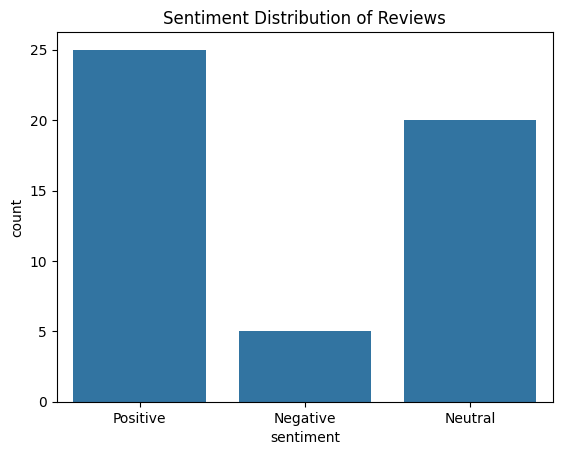

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="sentiment")
plt.title("Sentiment Distribution of Reviews")
plt.show()

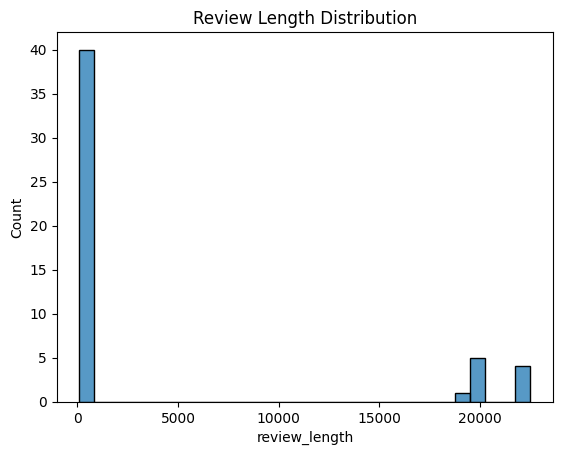

In [5]:
df["review_length"] = df["clean_text"].apply(len)

sns.histplot(df["review_length"], bins=30)
plt.title("Review Length Distribution")
plt.show()

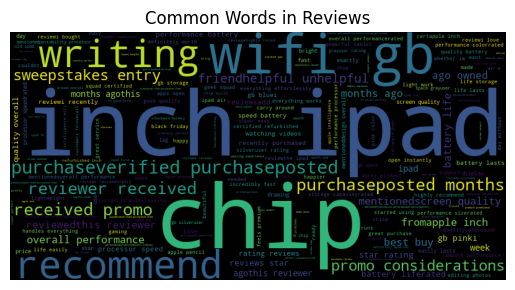

In [6]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Common Words in Reviews")
plt.show()

In [7]:
positive_reviews = df[df["sentiment"] == "Positive"]
negative_reviews = df[df["sentiment"] == "Negative"]

print("Sample Positive Review:")
print(positive_reviews["text"].iloc[0])

print("\nSample Negative Review:")
print(negative_reviews["text"].iloc[0])

Sample Positive Review:
Best BuyComputers & TabletsTabletsApple iPadiPadProduct DetailsCustomer Ratings & ReviewsNo contentSee more imagesApple - 11-inch iPad A16 chip with Wi-Fi - 128GB - SilverModel:MD3Y4LL/A|SKU:6578266User rating, 4.9 out of 5 stars with 14639 reviews.4.9(14,639 Reviews)Highly rated by customers for:Overall Performance,Portability,Battery Life$299.00Save $50Comp. Value:$349.00Deal ends Apr 1, 2026Add to cartCustomer reviews4.9Rating 4.9 out of 5 stars with 14645 reviews(14,645 customer reviews)5 star rating. 13,528 reviews513,5284 star rating. 797 reviews47973 star rating. 106 reviews31062 star rating. 44 reviews2441 star rating. 153 reviews1153Rating by featureBattery Life4.8Rating 4.8 out of 5 starsDurability4.8Rating 4.8 out of 5 starsDisplay4.9Rating 4.9 out of 5 starsPros mentionedfilterOverall performance(5,839)Portability(1,430)Battery life(1,222)Cons mentionedfilterConnectivity(20)Weight(17)Customer service(14)98%would recommend to a friend+1850imagesCustom

## Key Insights

### 1. Overall Sentiment
- Majority of reviews are **Positive**
- Indicates strong customer satisfaction

### 2. Key Drivers of Satisfaction
- Product quality and performance
- Ease of use
- Value for money

### 3. Common Issues Identified
- Some users reported performance issues
- Price sensitivity in negative reviews
- Occasional durability concerns

### 4. Customer Behavior
- Positive reviews tend to be shorter and direct
- Negative reviews are more detailed and descriptive

---

## Business Recommendations

- Focus on improving product durability
- Address common negative feedback areas
- Highlight strengths (quality, performance) in marketing
- Monitor negative sentiment for early issue detection

## Challenges & Solutions

### Challenge:
- BestBuy website blocked automated scraping using Selenium

### Solution:
- Implemented a hybrid approach by extracting rendered HTML manually
- Parsed HTML using BeautifulSoup for reliable data extraction

### Future Improvements:
- Use proxy rotation for full automation
- Implement retry mechanisms
- Use advanced scraping frameworks